### Anova
###### Teknik statis yang digunakan untuk mebandingkan rata-rata antar kelompok

In [ ]:
#Package

import numpy as np
import pandas as pd
import scipy.stats as stats
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# membuat contoh data
np.random.seed(123)
metode_1 = np.random.normal(loc=75 ,scale=10 , size=30)
metode_2 = np.random.normal(loc=80 ,scale=8 , size=30)
metode_3 = np.random.normal(loc=78 ,scale=9 , size=30)

# gabungkan data ke dalam satu data frame
df = pd.DataFrame({
    'nilai': np.concatenate([metode_1, metode_2, metode_3]),
    'metode': ['Metode 1'] * 30 + ['Metode 2'] * 30 + ['Metode 3'] * 30
    
})

# Lakukan Anova
model = ols('nilai ~ metode', data = df).fit()
anova_result = anova_lm(model)
print(anova_result) 


# mendapatkan p-value untuk faktor "metode"
p_value_metode = anova_result["PR(>F)"].iloc[0]

# Menentukan Hipothesis
# H0: Tidak ada perbedaan rata-rata nilai antara metode pembelajaran
# H1: Ada perbedaan rata-rata nilai antara metode pembelajaran

alpha = 0.05 # tingkat signifikansi yang umum digunakan

# logika if -else berdasarkan p value
if p_value_metode < alpha:
    print(f"p-value untuk metode: {p_value_metode:.5f} < {alpha}")
    print("Hasil: Tolak H0. Ada perbedaan signifikan antara metode pembelajaran.")
else:
    print(f"p-value untuk metode: {p_value_metode:.5f} >= {alpha}")
    print("Hasil: Gagal menolak H0. Tidak ada perbedaan signifikan antara metode pembelajaran.")


            df       sum_sq     mean_sq         F   PR(>F)
metode     2.0   504.706173  252.353086  2.296781  0.10665
Residual  87.0  9558.906913  109.872493       NaN      NaN
p-value untuk metode: 0.10665 >= 0.05
Hasil: Gagal menolak H0. Tidak ada perbedaan signifikan antara metode pembelajaran.


#### Two ways Anova
###### Dengan menambahkan satu yaitu jenis kelamin

In [14]:
# Menambahkan faktor kedua (misalnya, jenis kelamin)

jenis_kelamin = ['Laki-laki'] * 15 + ['Perempuan'] * 15

# Membuat DataFrame baru dengan faktor tambahan

df_2 = pd.DataFrame({
    'nilai': np.concatenate([metode_1, metode_2, metode_3]),
    'metode': ['Metode 1'] * 30 + ['Metode 2'] * 30 + ['Metode 3'] * 30,
    'jenis_kelamin': jenis_kelamin * 3
})
# Lakukan ANOVA dua arah

model_2 = ols('nilai ~ metode * jenis_kelamin', data=df_2).fit()
anova_result_2 = anova_lm(model_2)
print(anova_result_2)

# Mendapatkan p-value untuk faktor 'metode', 'jenis_kelamin', dan 'interaksi metode:jenis_kelamin'

p_value_metode = anova_result_2["PR(>F)"]["metode"]
p_value_jenis_kelamin = anova_result_2["PR(>F)"]["jenis_kelamin"]
p_value_interaksi = anova_result_2["PR(>F)"]["metode:jenis_kelamin"]

# Hipotesis untuk ANOVA dua arah:
# 1. H0 (metode): Tidak ada perbedaan signifikan antara metode pembelajaran.
# 2. H0 (jenis_kelamin): Tidak ada perbedaan signifikan antara jenis kelamin siswa.
# 3. H0 (interaksi metode:jenis_kelamin): Tidak ada interaksi signifikan antara metode pembelajaran dan jenis kelamin.

alpha = 0.05 # Tingkat signifikansi 5%

# Logika if-else berdasarkan p-value untuk metode

if p_value_metode < alpha:
    print(f"p-value untuk metode: {p_value_metode:.5f} < {alpha}")
    print("Hasil: Tolak H0. Ada perbedaan signifikan antara metode pembelajaran.")
else:
    print(f"p-value untuk metode: {p_value_metode:.5f} >= {alpha}")
    print("Hasil: Gagal menolak H0. Tidak ada perbedaan signifikan antara metode pembelajaran.")
    
# Logika if-else berdasarkan p-value untuk jenis_kelamin

if p_value_jenis_kelamin < alpha:
    print(f"p-value untuk jenis_kelamin: {p_value_jenis_kelamin:.5f} < {alpha}")
    print("Hasil: Tolak H0. Ada perbedaan signifikan antara jenis kelamin.")
else:
    print(f"p-value untuk jenis_kelamin: {p_value_jenis_kelamin:.5f} >= {alpha}")
    print("Hasil: Gagal menolak H0. Tidak ada perbedaan signifikan antara jenis kelamin.")
    
# Logika if-else berdasarkan p-value untuk interaksi metode:jenis_kelamin

if p_value_interaksi < alpha:
    print(f"p-value untuk interaksi metode:jenis_kelamin: {p_value_interaksi:.5f} < {alpha}")
    print("Hasil: Tolak H0. Ada interaksi signifikan antara metode dan jenis kelamin.")
else:
    print(f"p-value untuk interaksi metode:jenis_kelamin: {p_value_interaksi:.5f} >= {alpha}")
    print("Hasil: Gagal menolak H0. Tidak ada interaksi signifikan antara metode dan jenis kelamin.")



                        df       sum_sq     mean_sq         F    PR(>F)
metode                 2.0   504.706173  252.353086  2.437739  0.093516
jenis_kelamin          1.0   624.128594  624.128594  6.029103  0.016134
metode:jenis_kelamin   2.0   239.156723  119.578362  1.155131  0.319969
Residual              84.0  8695.621596  103.519305       NaN       NaN
p-value untuk metode: 0.09352 >= 0.05
Hasil: Gagal menolak H0. Tidak ada perbedaan signifikan antara metode pembelajaran.
p-value untuk jenis_kelamin: 0.01613 < 0.05
Hasil: Tolak H0. Ada perbedaan signifikan antara jenis kelamin.
p-value untuk interaksi metode:jenis_kelamin: 0.31997 >= 0.05
Hasil: Gagal menolak H0. Tidak ada interaksi signifikan antara metode dan jenis kelamin.


#### Box Plot Untuk Anova satu arah

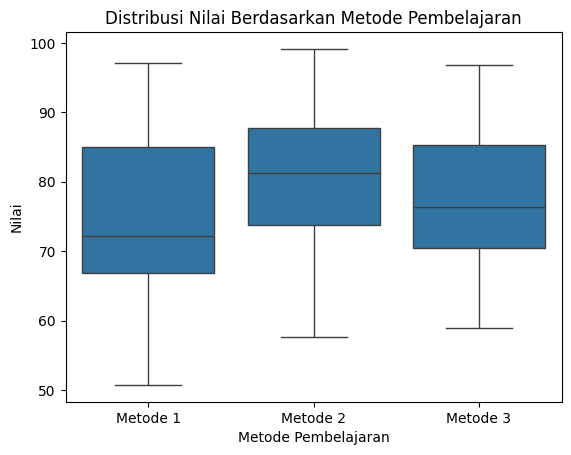

In [ ]:
# Visualisasi Box Plot Untuk Anova satu arah
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='metode', y='nilai', data=df)
plt.title("Distribusi Nilai Berdasarkan Metode Pembelajaran")
plt.xlabel("Metode Pembelajaran")
plt.ylabel("Nilai")
plt.show()

###### Penjelasan :Box plot ini akan membantu melihat apakah ada perbedaan distribusi nilai berdasarkan kategori metode

#### Interaction Plot untuk ANOVA satu arah


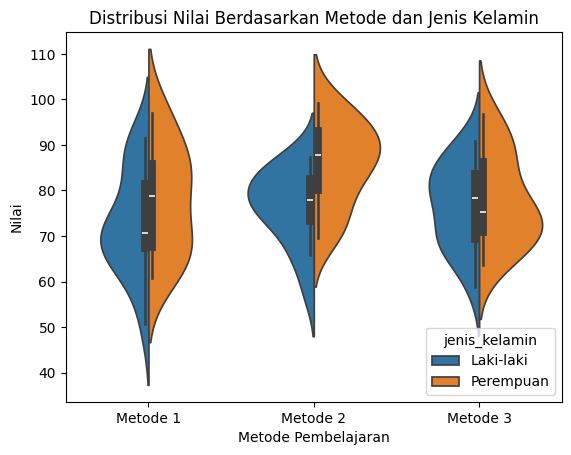

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.violinplot(x='metode', y='nilai', hue='jenis_kelamin', data=df_2, split=True)
plt.title("Distribusi Nilai Berdasarkan Metode dan Jenis Kelamin")
plt.xlabel("Metode Pembelajaran")
plt.ylabel("Nilai")
plt.show()


###### Penjelasan : Plot interaksi ini menampilkan bagaimana interaksi antara metode jenis kelamin mempengaruhi nilai rata-rata

#### Bar Plot dengan error bars untuk ANOVA dua arah:


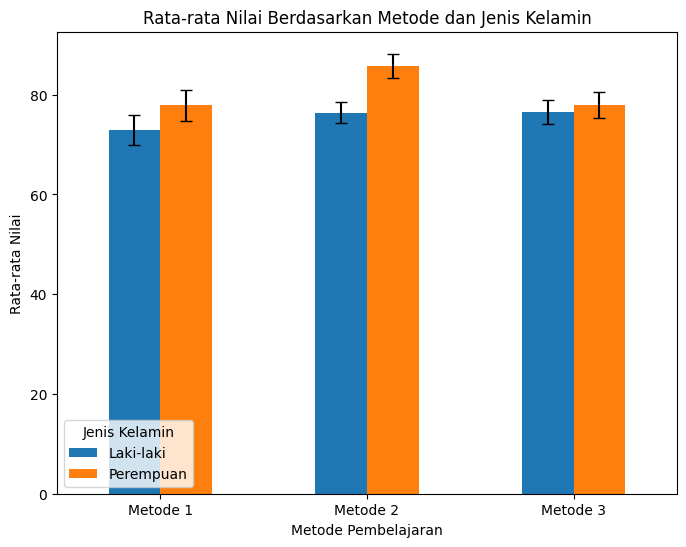

In [16]:
# Menghitung rata-rata dan standar error

means = df_2.groupby(['metode', 'jenis_kelamin'])['nilai'].mean().unstack()
errors = df_2.groupby(['metode', 'jenis_kelamin'])['nilai'].sem().unstack() # Standard Error

# Visualisasi Bar Plot dengan Error Bars

means.plot(kind='bar', yerr=errors, capsize=4, figsize=(8, 6))
plt.title("Rata-rata Nilai Berdasarkan Metode dan Jenis Kelamin")
plt.ylabel("Rata-rata Nilai")
plt.xlabel("Metode Pembelajaran")
plt.xticks(rotation=0)
plt.legend(title='Jenis Kelamin')
plt.show()


###### Penjelasan: Bar plot ini menampilkan rata-rata  nilai dengan eror bars masing-masing kombinasi faktor metode dan jenis_kelamin .Eror bars membantu memperlihatkan rentang ketidakpastian dari rata -rata tersebut(menggunakan standar erors)

#### Violin plot untuk distribusi nilai

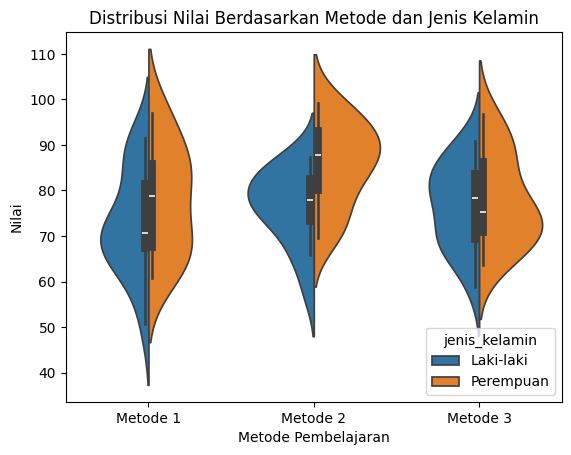

In [18]:
sns.violinplot(x='metode', y='nilai', hue='jenis_kelamin', data=df_2, split=True)
plt.title("Distribusi Nilai Berdasarkan Metode dan Jenis Kelamin")
plt.xlabel("Metode Pembelajaran")
plt.ylabel("Nilai")
plt.show()


###### Penjelasan : Violin plot adalah visualisai distribusi yang memperlihatkan kepadatan data pada setiap kategori.Split berdasarkan jenis kelamin untuk melihat perbedaan distribusi dalam metode pembelajaran